# Machine learning approach 

During this notebook, we are testing different ML algorithms to tackle hypoglycemia prediction problem  

Create our own class to compare different models against several horizons and metrics

In [44]:
import os 
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.path.append("..")
from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

In [3]:
class Models_Horizon():
    def __init__(self, cut_point:int, test_size:float , window_size:int, horizon:int, models:list, model_names:list):
        self.cut_point = cut_point
        self.test_size = test_size
        self.window_size = window_size
        self.horizon = horizon
        self.models = models
        self.model_names = model_names
        self.patients = self.load_patients()
        self.results = None
    
    def load_patients(self):
        data_dir = '../Data/Preprocessed'
        base_paths = os.listdir(data_dir)
        full_paths = [os.path.join(data_dir, p) for p in base_paths]
        patients = {}
        for i, fp in enumerate(full_paths):
            key = base_paths[i].split('.')[0]
            data = pd.read_csv(fp, sep=';')[:self.cut_point]
            proper_ml_data = Window_Regressor_Sequence_to_scalar(time_series_data=data['glucose'], window_size=self.window_size, horizon=self.horizon)
            patients[key] = proper_ml_data.generated_data_set
        return patients
    
    def test_models(self):
        keys = list(self.patients.keys())
        results = []
        for k in keys:
            data = self.patients[k]
            columns = data.columns
            X, y = data[columns[:-1]], data[columns[-1]]
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=self.test_size, shuffle=False)
            row_mse = []
            row_mae = []
            row_mape = []
            for model in self.models:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                mse, mae, mape = mean_squared_error(y_true=y_test, y_pred=y_pred), mean_absolute_error(y_true=y_test, y_pred=y_pred), mean_absolute_percentage_error(y_true=y_test, y_pred=y_pred)
                row_mse.append(mse)
                row_mae.append(mae)
                row_mape.append(mape)
            results.append(row_mse + row_mae + row_mape)
        ### Prepare and return a df 
        metrics = ['mse', 'mae', 'mape']
        col_index = pd.MultiIndex.from_product([metrics, self.model_names], names=['metric', 'model'])
        df_final = pd.DataFrame(
            results,
            index=keys,
            columns=col_index
        )
        self.results = df_final
        return df_final
    
    def visualize_model_comparison(self, figsize=(15, 7)):
        if self.results is None:
            raise ValueError("No results to visualize. Run 'test_models()' first.")
    

        metrics = ['mse', 'mae', 'mape']
        model_names = self.model_names

        _, axes = plt.subplots(1, 3, figsize=figsize)
        colors = ['steelblue', 'seagreen', 'tomato']

        for ax, metric, color in zip(axes, metrics, colors):

            data_plot = self.results[metric]  

            data_long = data_plot.reset_index().melt(
                id_vars='index',
                var_name='Model',
                value_name=metric.upper()
            )
            data_long['Model'] = pd.Categorical(data_long['Model'], categories=model_names)

    
            sns.boxplot(
                data=data_long,
                x='Model',
                y=metric.upper(),
                ax=ax,
                color=color,
                width=0.6
            )

            ax.set_title(f'{metric.upper()}: Window_size:{self.window_size}, Horizon:{self.horizon}')
            ax.set_xlabel('Modelo')
            ax.set_ylabel(metric.upper())
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()
        
        ## Visualize a summary for each metric
        for m in metrics:
            print(f'{m.upper()}')
            print(self.results[m].describe())
        

## Test it using random forest regressor and gradient boost regressor 

In [4]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

In [5]:
cut_point = 2290
test_size = 0.2
window_size = 6
horizon = 12
models = [
    RandomForestRegressor(
        n_estimators=100,
        criterion='squared_error',
        max_depth=6
    ),
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        criterion='squared_error'
    ),
    XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective='reg:squarederror'
    ),
    LinearRegression()
]
model_names = ['random_forest', 'gradient_boost', 'xgboost', 'linear_regression']

In [6]:
horizon_3 = Models_Horizon(
    cut_point=cut_point, 
    test_size=test_size, 
    window_size=window_size, 
    horizon=horizon, 
    models=models, 
    model_names=model_names
)

In [7]:
results = horizon_3.test_models()

In [8]:
results

metric              mse                 ...      mape                  
model     random_forest gradient_boost  ...   xgboost linear_regression
HUPA0004P   1943.282672    1906.704863  ...  0.247392          0.216893
HUPA0006P   1780.522174    1891.245375  ...  0.216305          0.177616
HUPA0007P   2720.268174    2705.105243  ...  0.276470          0.295932
HUPA0009P    353.620530     317.653933  ...  0.051245          0.052712
HUPA0005P    745.050891     859.423196  ...  0.139494          0.109855
HUPA0011P   1693.394282    1811.520046  ...  0.196747          0.163204
HUPA0003P   1155.877448    1173.293612  ...  0.232669          0.233438
HUPA0001P   4073.089500    4501.749058  ...  0.209864          0.212850
HUPA0010P    596.264644     560.404437  ...  0.170279          0.216764
HUPA0002P    674.736925     769.648865  ...  0.231718          0.204721
HUPA0014P   3300.170263    3086.939840  ...  0.183239          0.160229
HUPA0015P   1765.230655    1845.949523  ...  0.223812          0.192250
HUPA0016P   1894.843262    2066.983903  ...  0.235280          0.191202
HUPA0017P   1058.083036    1272.485308  ...  0.157493          0.138066
HUPA0018P   1097.744369    1187.295662  ...  0.189022          0.171822
HUPA0021P   1267.060990    1317.522966  ...  0.175290          0.165653
HUPA0020P   1359.978929    1427.977597  ...  0.182033          0.152233
HUPA0024P    908.375808    1162.736884  ...  0.132123          0.107544
HUPA0019P   2167.131402    2182.632829  ...  0.239500          0.196263
HUPA0023P    729.725759     766.692470  ...  0.140772          0.127002
HUPA0022P    640.317492     661.533055  ...  0.163781          0.159121
HUPA0025P    592.875722     623.962291  ...  0.206473          0.205959
HUPA0028P    907.150183     900.081915  ...  0.270444          0.270745
HUPA0026P   1945.955045    2066.766726  ...  0.265952          0.220578
HUPA0027P   1108.540154    1161.675182  ...  0.211589          0.176419

[25 rows x 12 columns]

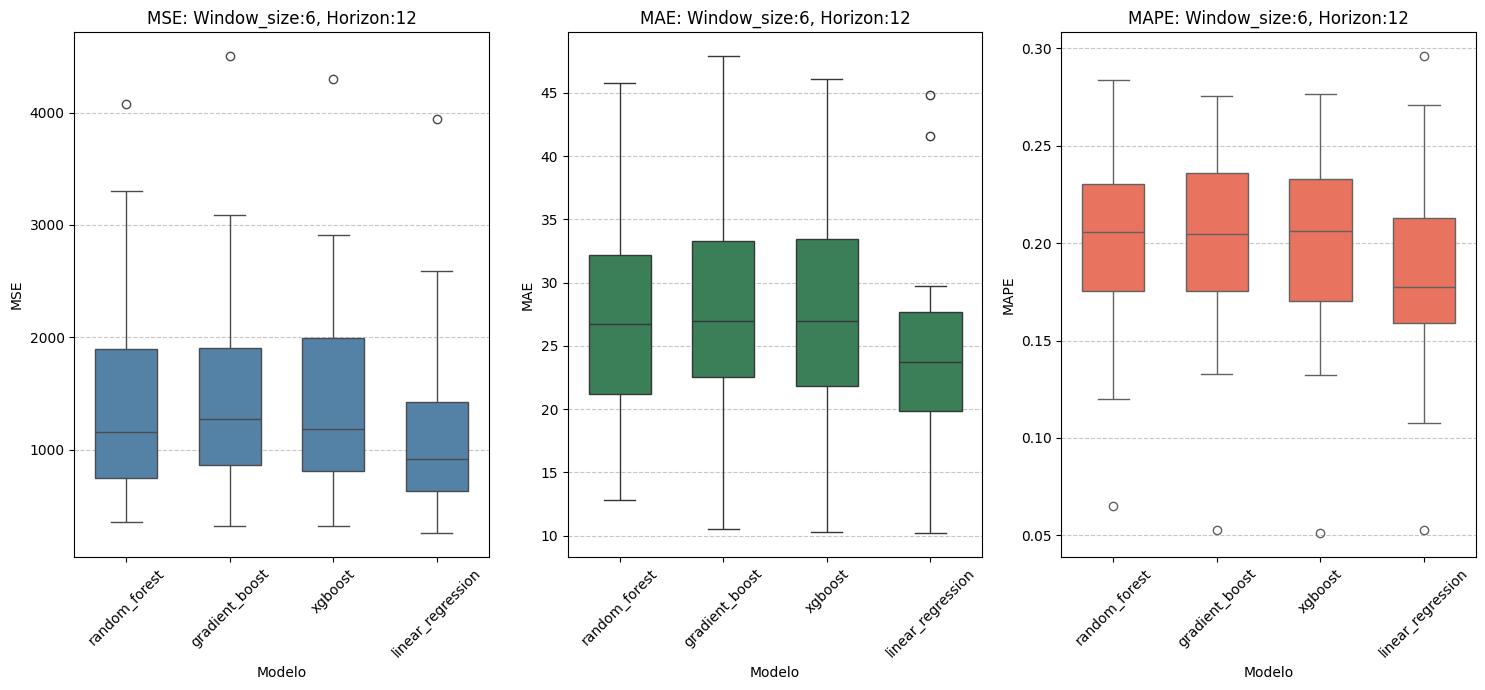

MSE
model  random_forest  gradient_boost      xgboost  linear_regression
count      25.000000       25.000000    25.000000          25.000000
mean     1459.171612     1529.119391  1507.966854        1175.659029
std       899.834820      929.145424   898.239358         762.602407
min       353.620530      317.653933   317.742026         257.267279
25%       745.050891      859.423196   812.163994         633.059970
50%      1155.877448     1272.485308  1180.074372         912.181887
75%      1894.843262     1906.704863  1992.030752        1419.774208
max      4073.089500     4501.749058  4297.489528        3944.787050
MAE
model  random_forest  gradient_boost    xgboost  linear_regression
count      25.000000       25.000000  25.000000          25.000000
mean       27.696609       28.102678  28.025498          24.724075
std         7.513547        7.865402   7.852773           7.184492
min        12.818919       10.488310  10.258480          10.201372
25%        21.166212       22.567099

In [9]:
horizon_3.visualize_model_comparison()

In [11]:
from sklearn.model_selection import TimeSeriesSplit

In [12]:
glucose = pd.read_csv('../Data/Preprocessed/HUPA0002P.csv', sep=';')['glucose']

In [13]:
glucose

0        86.000000
1        82.000000
2        78.000000
3        74.000000
4        76.666667
           ...    
3176    104.000000
3177    107.000000
3178    110.666667
3179    114.333333
3180    118.000000
Name: glucose, Length: 3181, dtype: float64

In [37]:
cross_val = TimeSeriesSplit(n_splits=5, test_size=288)

In [39]:
glucose.shape

(3181,)

In [43]:
for x in cross_val.split(glucose[:2290]):
    print(x[0][-1])

849
1137
1425
1713
2001
